# Shapash in Jupyter - GLM Regression Overview

This tutorial shows how to:
- train a GLM regressor on House Prices data
- evaluate predictions
- use Shapash for global and local explainability
- optionally launch the Shapash webapp

In [ ]:
import numpy as np
import pandas as pd

from category_encoders import one_hot
from sklearn.linear_model import GammaRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from shapash import SmartExplainer
from shapash.data.data_loader import data_loading

## 1. Build a GLM regressor

In [2]:
house_df, house_dict = data_loading('house_prices')
house_df.head()

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,2-Story 1946 & Newer,Residential Low Density,8450,Paved,Regular,Near Flat/Level,"All public Utilities (E,G,W,& S)",Inside lot,Gentle slope,College Creek,...,0,0,0,0,0,2,2008,Warranty Deed - Conventional,Normal Sale,208500
2,1-Story 1946 & Newer All Styles,Residential Low Density,9600,Paved,Regular,Near Flat/Level,"All public Utilities (E,G,W,& S)",Frontage on 2 sides of property,Gentle slope,Veenker,...,0,0,0,0,0,5,2007,Warranty Deed - Conventional,Normal Sale,181500
3,2-Story 1946 & Newer,Residential Low Density,11250,Paved,Slightly irregular,Near Flat/Level,"All public Utilities (E,G,W,& S)",Inside lot,Gentle slope,College Creek,...,0,0,0,0,0,9,2008,Warranty Deed - Conventional,Normal Sale,223500
4,2-Story 1945 & Older,Residential Low Density,9550,Paved,Slightly irregular,Near Flat/Level,"All public Utilities (E,G,W,& S)",Corner lot,Gentle slope,Crawford,...,272,0,0,0,0,2,2006,Warranty Deed - Conventional,Abnormal Sale,140000
5,2-Story 1946 & Newer,Residential Low Density,14260,Paved,Slightly irregular,Near Flat/Level,"All public Utilities (E,G,W,& S)",Frontage on 2 sides of property,Gentle slope,Northridge,...,0,0,0,0,0,12,2008,Warranty Deed - Conventional,Normal Sale,250000


In [3]:
y = house_df['SalePrice']
X = house_df[house_df.columns.difference(['SalePrice'])].copy()

categorical_features = [col for col in X.columns if X[col].dtype == 'object']

# For GLM, one-hot encoding is safer for nominal categorical variables
encoder = one_hot.OneHotEncoder(
    cols=categorical_features,
    use_cat_names=True
).fit(X)

X = encoder.transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.75,
    random_state=1
)

X_train.shape, X_test.shape

((1095, 282), (365, 282))

In [4]:
# Scale features before fitting GLM to improve optimizer convergence
glm_regressor = make_pipeline(
    StandardScaler(),
    GammaRegressor(alpha=0.01, max_iter=10000)
 )
glm_regressor.fit(X_train, y_train)

y_pred_values = glm_regressor.predict(X_test)

metrics = pd.Series(
    {
        'MAE': [mean_absolute_error(y_test, y_pred_values)],
        'RMSE': [root_mean_squared_error(y_test, y_pred_values)],
        'R2': [r2_score(y_test, y_pred_values)],
    }
)
metrics

MAE     [14839.960193657058]
RMSE     [21797.67635499144]
R2      [0.9292235133732485]
dtype: object

## 2. Compile SmartExplainer

In [5]:
y_pred = pd.DataFrame(y_pred_values, columns=['pred'], index=X_test.index)
y_target = y_test.to_frame(name='SalePrice')

xpl = SmartExplainer(
    model=glm_regressor,
    preprocessing=encoder,
    features_dict=house_dict,
    title_story='House Prices - GLM Regressor'
)

xpl.compile(
    x=X_test,
    y_pred=y_pred,
    y_target=y_target
)

INFO: Shap explainer type - shap.explainers.PermutationExplainer()


## 3. Explainability in notebook

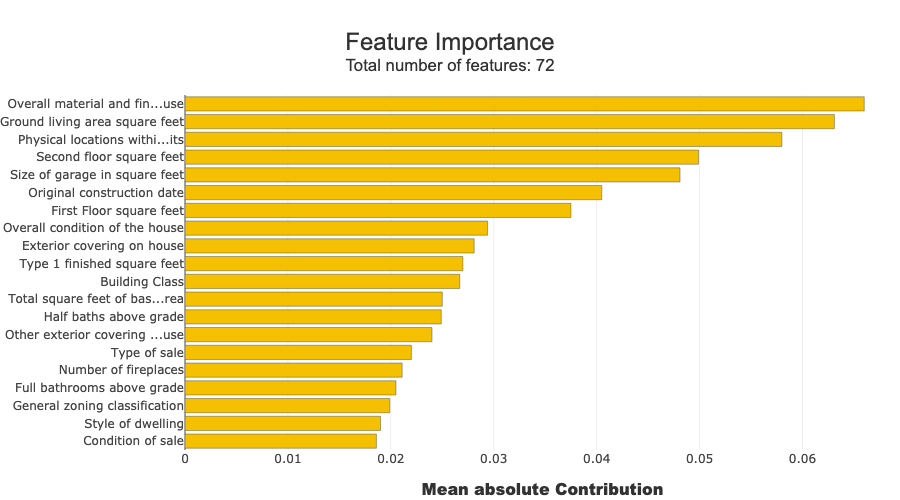

In [6]:
xpl.plot.features_importance()

In [7]:
fig = xpl.plot.contribution_plot('OverallQual')

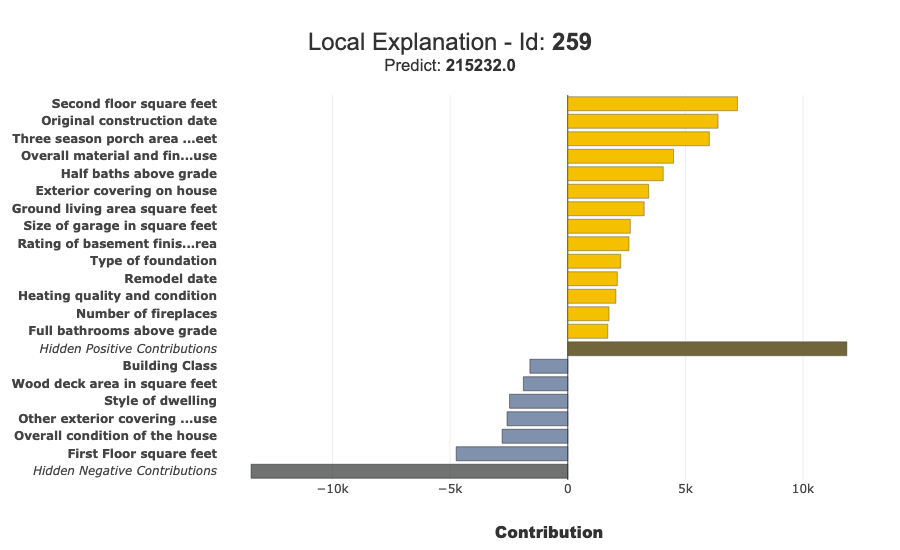

In [8]:
first_index = X_test.index[0]
xpl.plot.local_plot(index=first_index)

In [9]:
xpl.to_pandas(max_contrib=8).head(10)

,pred,feature_1,value_1,contribution_1,feature_2,value_2,contribution_2,feature_3,value_3,contribution_3,...,contribution_5,feature_6,value_6,contribution_6,feature_7,value_7,contribution_7,feature_8,value_8,contribution_8
259,215231.510661,Second floor square feet,829,7212.75529,Original construction date,2001,6387.987536,Three season porch area in square feet,245,6019.076585,...,4495.137907,Half baths above grade,1,4058.735982,Exterior covering on house,Vinyl Siding,3440.485441,Ground living area square feet,1792,3248.712227
268,160397.678094,Building Class,2-1/2 Story All Ages,-21612.884252,Overall condition of the house,8,12250.944277,Ground living area square feet,2192,10575.561484,...,-9545.699803,Low quality finished square feet,420,9028.738252,Original construction date,1939,-7836.722046,Rating of basement finished area,Low Quality,-5422.044481
289,115701.508983,Ground living area square feet,900,-12626.35656,Overall material and finish of the house,5,-8356.89129,Size of garage in square feet,280,-7095.89495,...,-4334.867376,Full bathrooms above grade,1,-3159.065666,Physical locations within Ames city limits,Sawyer,-3075.744804,Number of fireplaces,0,-3056.889288
650,80205.258207,Physical locations within Ames city limits,Meadow Village,-17473.852842,Ground living area square feet,630,-14787.896977,Size of garage in square feet,0,-14247.389586,...,-11790.654848,Exterior covering on house,Cement Board,-10484.672846,Style of dwelling,Split Foyer,-7235.055635,First Floor square feet,630,-6718.703928
1234,130344.536158,Condition of sale,Abnormal Sale,-9608.452839,Overall material and finish of the house,5,-8885.747137,Ground living area square feet,1188,-8100.302992,...,-5756.506194,Type 1 finished square feet,1000,4126.536304,Heating quality and condition,Fair,-4000.527692,Full bathrooms above grade,1,-3461.324322
168,352193.512148,Type of sale,Home just constructed and sold,27423.64341,Physical locations within Ames city limits,Northridge Heights,26264.829848,Overall material and finish of the house,8,15713.549155,...,15303.678926,Kitchen quality,Excellent,13895.520143,Condition of sale,Home wasn't completed,-13460.690594,Type 1 finished square feet,1288,10685.074459
927,295017.319098,Physical locations within Ames city limits,Northridge Heights,23176.411653,Ground living area square feet,2374,19431.401488,Second floor square feet,1140,15255.715262,...,12034.304356,Original construction date,2003,8068.794323,Size of garage in square feet,656,7847.434879,Type 1 finished square feet,0,-5794.106906
832,154075.134016,Building Class,2-Story PUD-1946 & Newer,-13398.22308,First Floor square feet,520,-11003.949501,Ground living area square feet,1200,-8430.064484,...,6333.763524,Total square feet of basement area,600,-4856.809903,General zoning classification,Floating Village Residential,4332.979451,Type 1 finished square feet,0,-4234.924633
1238,202185.042361,Second floor square feet,1101,11612.437376,Original construction date,2004,6908.342505,First Floor square feet,847,-6712.185727,...,-4905.248373,Overall material and finish of the house,7,4247.437853,Half baths above grade,1,3896.85019,Exterior covering on house,Vinyl Siding,3281.530173
427,245162.694436,Screen porch area in square feet,396,16317.597159,Type 1 finished square feet,1518,11626.876519,Refers to walkout or garden level walls,Good Exposure,10301.282465,...,-9292.625571,First Floor square feet,1644,8228.216186,Second floor square feet,0,-7922.166877,Building Class,Split or Multi-Level,-7435.296436


## 4. Optional: launch webapp

Like in `shapash/webapp/webapp_launch_DVF.py`, you can launch the app from the compiled explainer.

In [10]:
# xpl.init_app()
# app = xpl.smartapp.app
# app.run_server(debug=False, host='0.0.0.0', port=8080)